<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/Project_4_Text_Length_Analysis_(Exploratory_Data_Analysis_EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 4: Text Length Analysis (Exploratory Data Analysis - EDA)**

## Objective

In this project, we will analyze the length of news titles and descriptions. This is an important EDA step because it helps you understand:

* Average title length
* Average description length
* Shortest and longest news articles
* Word count distribution
* Character count distribution

This information is useful when preparing data for **RNNs, LSTMs, Transformers, and BERT**, as these models often have maximum input length limits.

---

# Step 1: Import Libraries

In [245]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.feature_extraction.text import CountVectorizer
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from google.colab import drive
import string


In [246]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [247]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Step 2: Load Dataset

In [248]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bbc_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


---

In [249]:
df = df.dropna(subset=["description"])
df = df.drop_duplicates(subset=["description"])
df = df.reset_index(drop=True)

In [250]:
df = df.drop(columns=['guid', 'link','pubDate'])
df.head()

,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


##data cleaning


In [251]:
# Initialize
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove @mentions
    text = re.sub(r'@\w+', ' ', text)

    # Remove # but keep the word
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove special characters (keep only alphabets and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    # Join back into text
    return " ".join(words)

# Apply preprocessing
df['clean_text_title'] = df['title'].apply(preprocess_text)
df['clean_text_description'] = df['description'].apply(preprocess_text)

In [252]:
df['clean_text_title'].head()

,clean_text_title
0,ukraine angry zelensky vow punish russian atro...
1,war ukraine taking cover town attack
2,ukraine war catastrophic global food
3,manchester arena bombing saffie roussoss paren...
4,ukraine conflict oil price soar highest level ...


In [253]:
df['clean_text_description'].head()

,clean_text_description
0,ukrainian president say country forgive forget...
1,jeremy bowen frontline irpin resident came rus...
2,one world biggest fertiliser firm say conflict...
3,parent manchester arena bombing youngest victi...
4,consumer feeling impact higher energy cost fue...


# Step 3: Calculate Character Length

### Title Characters

In [254]:
df["title_characters"] = df["clean_text_title"].str.len()
df.head()

,title,description,clean_text_title,clean_text_description,title_characters
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,ukraine angry zelensky vow punish russian atro...,ukrainian president say country forgive forget...,50
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...",war ukraine taking cover town attack,jeremy bowen frontline irpin resident came rus...,36
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,ukraine war catastrophic global food,one world biggest fertiliser firm say conflict...,36
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...,manchester arena bombing saffie roussoss paren...,parent manchester arena bombing youngest victi...,61
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,ukraine conflict oil price soar highest level ...,consumer feeling impact higher energy cost fue...,51


### Description Characters

In [255]:
df["description_characters"] = df["clean_text_description"].str.len()
df.head()

,title,description,clean_text_title,clean_text_description,title_characters,description_characters
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,ukraine angry zelensky vow punish russian atro...,ukrainian president say country forgive forget...,50,62
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...",war ukraine taking cover town attack,jeremy bowen frontline irpin resident came rus...,36,67
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,ukraine war catastrophic global food,one world biggest fertiliser firm say conflict...,36,78
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...,manchester arena bombing saffie roussoss paren...,parent manchester arena bombing youngest victi...,61,69
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,ukraine conflict oil price soar highest level ...,consumer feeling impact higher energy cost fue...,51,73


---

# Step 4: Calculate Word Count

### Title Word Count

In [256]:
df["title_words"] = df["clean_text_title"].str.split().apply(len)
df.head()

,title,description,clean_text_title,clean_text_description,title_characters,description_characters,title_words
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,ukraine angry zelensky vow punish russian atro...,ukrainian president say country forgive forget...,50,62,7
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...",war ukraine taking cover town attack,jeremy bowen frontline irpin resident came rus...,36,67,6
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,ukraine war catastrophic global food,one world biggest fertiliser firm say conflict...,36,78,5
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...,manchester arena bombing saffie roussoss paren...,parent manchester arena bombing youngest victi...,61,69,8
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,ukraine conflict oil price soar highest level ...,consumer feeling impact higher energy cost fue...,51,73,8


### Description Word Count

In [257]:
df["description_words"] = df["clean_text_description"].str.split().apply(len)
df.head()

,title,description,clean_text_title,clean_text_description,title_characters,description_characters,title_words,description_words
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,ukraine angry zelensky vow punish russian atro...,ukrainian president say country forgive forget...,50,62,7,8
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...",war ukraine taking cover town attack,jeremy bowen frontline irpin resident came rus...,36,67,6,10
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,ukraine war catastrophic global food,one world biggest fertiliser firm say conflict...,36,78,5,12
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...,manchester arena bombing saffie roussoss paren...,parent manchester arena bombing youngest victi...,61,69,8,10
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,ukraine conflict oil price soar highest level ...,consumer feeling impact higher energy cost fue...,51,73,8,11


---

# Step 5: Calculate Sentence Count

In [258]:
df["description_sentences"] = df["clean_text_description"].str.count(r"[.!?]") + 1
df.head()

,title,description,clean_text_title,clean_text_description,title_characters,description_characters,title_words,description_words,description_sentences
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...,ukraine angry zelensky vow punish russian atro...,ukrainian president say country forgive forget...,50,62,7,8,1
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as...",war ukraine taking cover town attack,jeremy bowen frontline irpin resident came rus...,36,67,6,10,1
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...,ukraine war catastrophic global food,one world biggest fertiliser firm say conflict...,36,78,5,12,1
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...,manchester arena bombing saffie roussoss paren...,parent manchester arena bombing youngest victi...,61,69,8,10,1
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...,ukraine conflict oil price soar highest level ...,consumer feeling impact higher energy cost fue...,51,73,8,11,1


---

# Step 6: View Dataset

In [259]:
df[[
    "title",
    "title_words",
    "title_characters",
    "description_words",
    "description_characters",
    "description_sentences"
]].head()

,title,title_words,title_characters,description_words,description_characters,description_sentences
0,Ukraine: Angry Zelensky vows to punish Russian...,7,50,8,62,1
1,War in Ukraine: Taking cover in a town under a...,6,36,10,67,1
2,Ukraine war 'catastrophic for global food',5,36,12,78,1
3,Manchester Arena bombing: Saffie Roussos's par...,8,61,10,69,1
4,Ukraine conflict: Oil price soars to highest l...,8,51,11,73,1


# Step 7: Statistical Summary

In [260]:
df[[
    "title_words",
    "description_words",
    "title_characters",
    "description_characters"
]].describe()

,title_words,description_words,title_characters,description_characters
count,33124.000000,33124.000000,33124.000000,33124.000000
mean,7.255857,10.783209,48.259510,74.687447
std,1.911300,2.690387,12.963132,18.497461
min,1.000000,2.000000,3.000000,12.000000
25%,6.000000,9.000000,40.000000,63.000000
50%,7.000000,10.000000,47.000000,71.000000
75%,8.000000,12.000000,56.000000,81.000000
max,17.000000,27.000000,119.000000,193.000000


# Step 8: Average Length

In [261]:
print("Average Title Words:",
      df["title_words"].mean())

print("Average Description Words:",
      df["description_words"].mean())

print("Average Title Characters:",
      df["title_characters"].mean())

print("Average Description Characters:",
      df["description_characters"].mean())

Average Title Words: 7.2558567805820555
Average Description Words: 10.783208549692066
Average Title Characters: 48.25950972104818
Average Description Characters: 74.6874471682164


---

# Step 9: Maximum and Minimum

In [262]:
print("Longest Title:",
      df["title_words"].max())

print("Shortest Title:",
      df["title_words"].min())

print("Longest Description:",
      df["description_words"].max())

print("Shortest Description:",
      df["description_words"].min())

Longest Title: 17
Shortest Title: 1
Longest Description: 27
Shortest Description: 2


---

# Step 10: Find Longest Title

In [263]:
longest = df.loc[
    df["title_words"].idxmax()
]

print(longest["title"])

Manchester City v Red Star Belgrade: John Stones, Jack Grealish, Mateo Kovacic and Kevin de Bruyne out of Champions League opener


---

# Step 11: Find Shortest Title

In [264]:
shortest = df.loc[
    df["title_words"].idxmin()
]

print(shortest["title"])

How hot is it where you are?


---

# Step 12: Histogram of Title Length

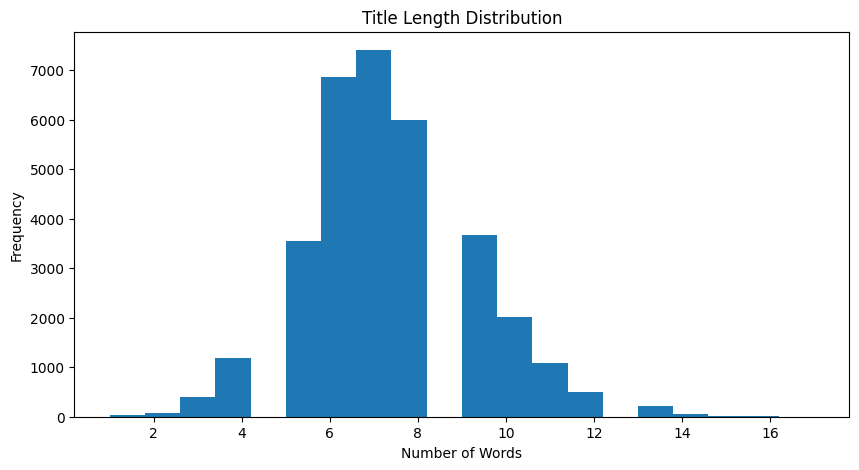

In [265]:
plt.figure(figsize=(10,5))

plt.hist(df["title_words"], bins=20)

plt.title("Title Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

---

# Step 13: Histogram of Description Length

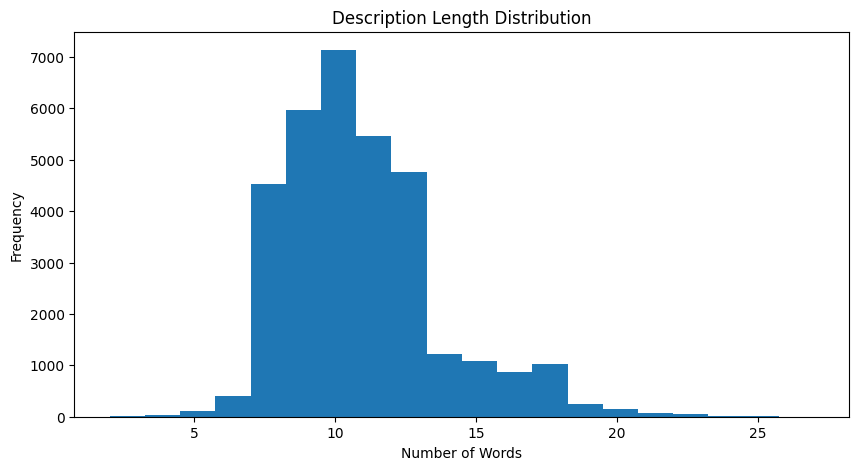

In [266]:
plt.figure(figsize=(10,5))

plt.hist(df["description_words"], bins=20)

plt.title("Description Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

---

# Step 14: Box Plot

This helps detect outliers.

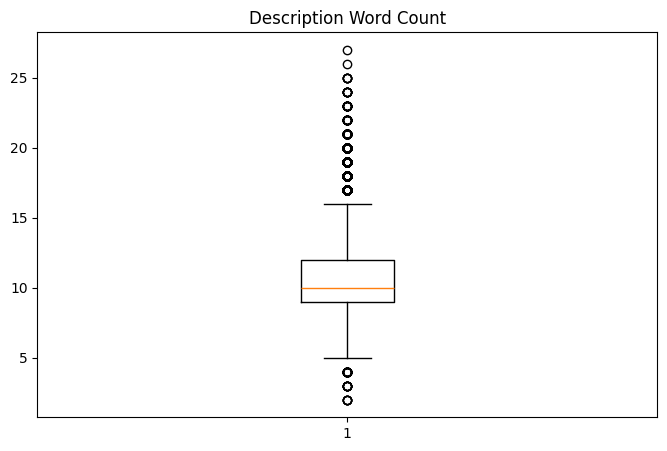

In [267]:
plt.figure(figsize=(8,5))

plt.boxplot(df["description_words"])

plt.title("Description Word Count")

plt.show()

---

# Step 15: Scatter Plot

Relationship between title and description length.

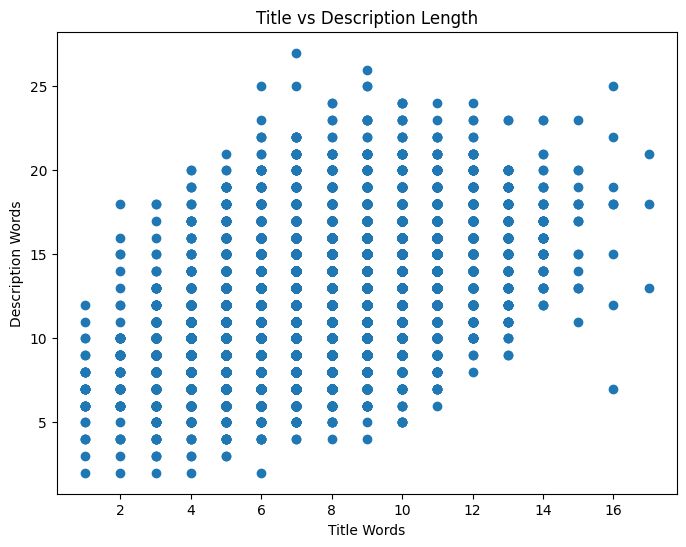

In [268]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["title_words"],
    df["description_words"]
)

plt.xlabel("Title Words")

plt.ylabel("Description Words")

plt.title("Title vs Description Length")

plt.show()

---

# Step 16: Correlation

In [269]:
correlation = df[
    ["title_words",
     "description_words"]
].corr()

print(correlation)

                   title_words  description_words
title_words           1.000000           0.429621
description_words     0.429621           1.000000


# Step 17: Save Dataset

In [270]:
df.to_csv(
    "news_length_analysis.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


---

# What You'll Learn

After completing this project, you'll be able to:

* Perform exploratory data analysis (EDA) on text datasets.
* Compute word, character, and sentence counts.
* Identify unusually short or long documents.
* Visualize text length distributions with histograms.
* Detect outliers using box plots.
* Explore relationships between title and description lengths.